<>:127: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_58/79127499.py:127: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('Surprisal Score ($-\log P$)')



--- Analyzing H1: Original vs Caroline across 3 Models ---
QWEN: Original=56.86%, Caroline=44.61%
GEMMA: Original=52.45%, Caroline=41.18%
MISTRAL: Original=45.59%, Caroline=37.75%
H1 Plot saved as Vector PDF: /kaggle/working/results/h1_accuracy_drop_all_models.pdf


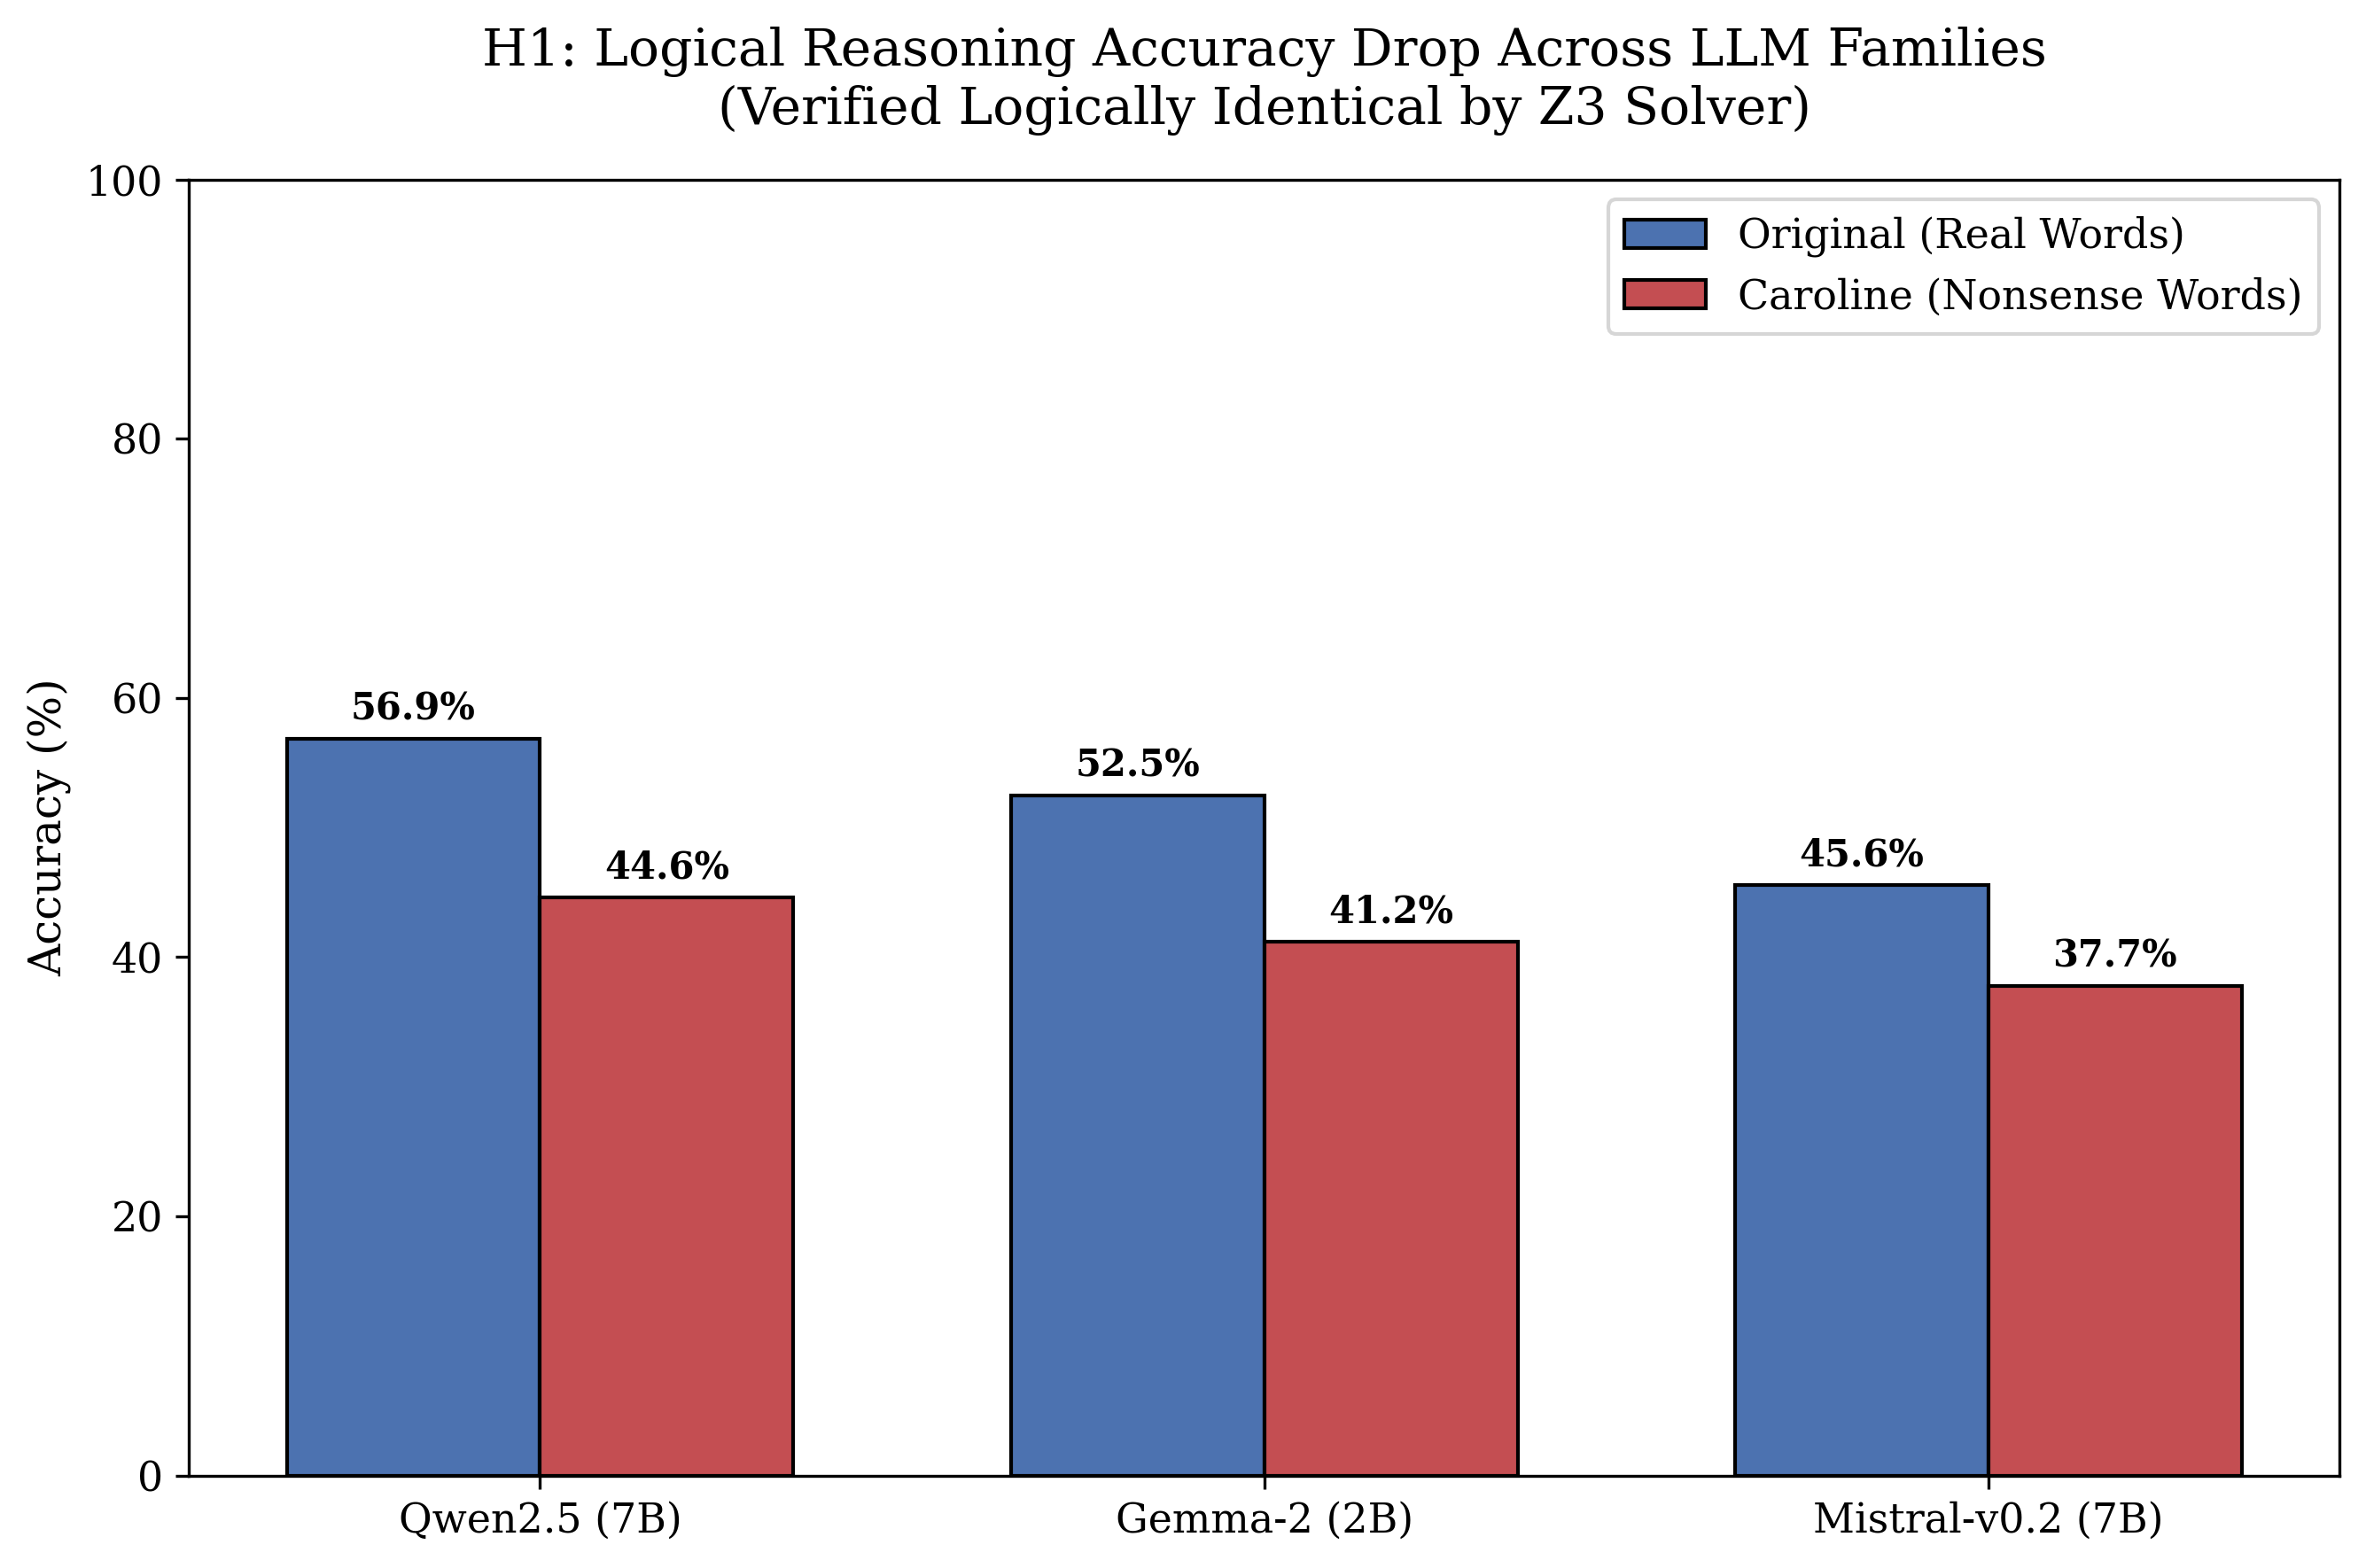


--- Analyzing H2: Quantifier Scoping Surprisal Across 3 Models ---
H2 Plot saved as Vector PDF: /kaggle/working/results/h2_surprisal_inconsistency_all_models.pdf


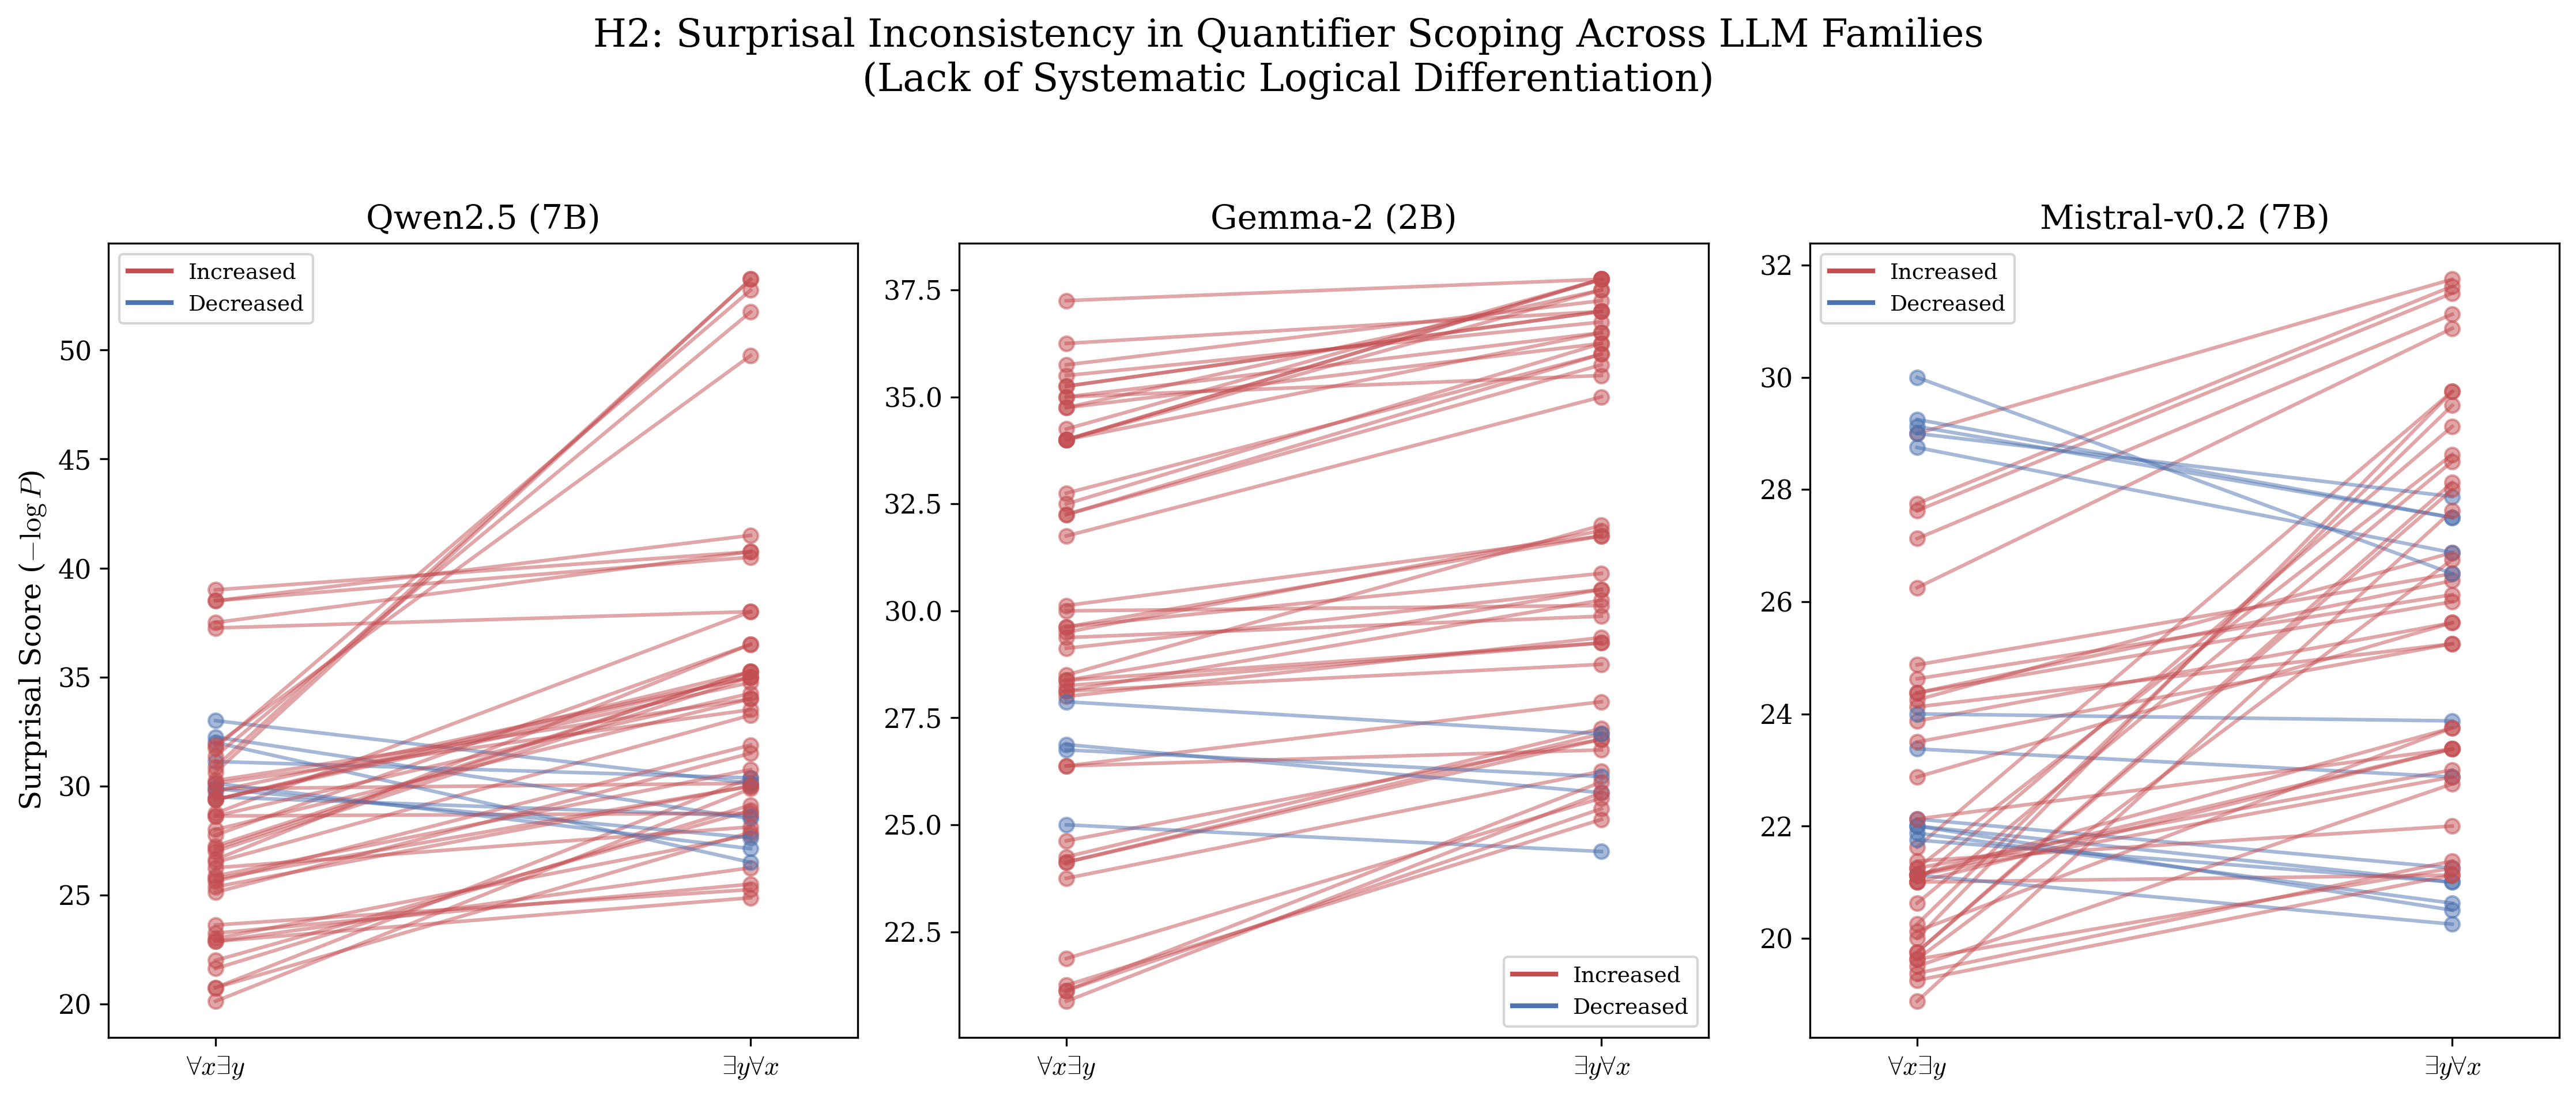


All tasks completed successfully! The Engineering Phase is 100% DONE! 🥂


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================================================
# Academic Plotting Configuration (LaTeX Fonts & Style)
# =========================================================
plt.rcParams.update({
    "font.family": "serif",        
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "text.usetex": False,          
    "mathtext.fontset": "cm",      
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 300              
})

# Create folder for saving plots
os.makedirs('/kaggle/working/results', exist_ok=True)

# Define models
models = ['qwen', 'gemma', 'mistral']
model_labels = ['Qwen2.5 (7B)', 'Gemma-2 (2B)', 'Mistral-v0.2 (7B)']
colors = ['#4C72B0', '#55A868', '#C44E52'] # Blue, Green, Red

# Load datasets
# UPDATE THIS PATH if your Kaggle dataset path is different!
h1_dir = '/kaggle/input/datasets/alirezaebrahimi/folio-h1-llm-answers' 
h2_file = '/kaggle/input/datasets/alirezaebrahimi/folio-h2-surprisal-data/surprisal_results_h2_all_models.csv' 

df_h2 = pd.read_csv(h2_file)

# =========================================================
# ANALYSIS 1: Hypothesis H1 (Accuracy Drop across 3 Models)
# =========================================================
print("\n--- Analyzing H1: Original vs Caroline across 3 Models ---")

acc_orig_list = []
acc_caroline_list = []

for model in models:
    file_path = f"{h1_dir}/llm_answers_h1_{model}.csv"
    df_h1 = pd.read_csv(file_path)
    
    df_h1['label'] = df_h1['label'].astype(str).str.strip().str.capitalize()
    df_h1['llm_answer_original'] = df_h1['llm_answer_original'].astype(str).str.strip().str.capitalize()
    df_h1['llm_answer_caroline'] = df_h1['llm_answer_caroline'].astype(str).str.strip().str.capitalize()

    acc_orig = (df_h1['label'] == df_h1['llm_answer_original']).mean() * 100
    acc_caroline = (df_h1['label'] == df_h1['llm_answer_caroline']).mean() * 100
    
    acc_orig_list.append(acc_orig)
    acc_caroline_list.append(acc_caroline)
    
    print(f"{model.upper()}: Original={acc_orig:.2f}%, Caroline={acc_caroline:.2f}%")

# Plot 1: Grouped Bar Chart
fig1, ax1 = plt.subplots(figsize=(9, 6))

x = np.arange(len(models))
width = 0.35

rects1 = ax1.bar(x - width/2, acc_orig_list, width, label='Original (Real Words)', color='#4C72B0', edgecolor='black')
rects2 = ax1.bar(x + width/2, acc_caroline_list, width, label='Caroline (Nonsense Words)', color='#C44E52', edgecolor='black')

ax1.set_ylabel('Accuracy (%)')
ax1.set_title('H1: Logical Reasoning Accuracy Drop Across LLM Families\n(Verified Logically Identical by Z3 Solver)', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 100)
ax1.legend()

# Add text labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
h1_plot_path_pdf = '/kaggle/working/results/h1_accuracy_drop_all_models.pdf'
plt.savefig(h1_plot_path_pdf, format='pdf', bbox_inches='tight')
print(f"H1 Plot saved as Vector PDF: {h1_plot_path_pdf}")
plt.show()

# =========================================================
# ANALYSIS 2: Hypothesis H2 (Quantifier Scoping Surprisal)
# =========================================================
print("\n--- Analyzing H2: Quantifier Scoping Surprisal Across 3 Models ---")

fig2, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)
fig2.suptitle('H2: Surprisal Inconsistency in Quantifier Scoping Across LLM Families\n(Lack of Systematic Logical Differentiation)', fontsize=16, y=1.05)

unique_pairs = df_h2['pair_id'].unique()
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#C44E52', lw=2),
                Line2D([0], [0], color='#4C72B0', lw=2)]

for idx, model in enumerate(models):
    ax = axes[idx]
    col_name = f'surprisal_score_{model}'
    
    for pid in unique_pairs:
        subset = df_h2[df_h2['pair_id'] == pid]
        if len(subset) == 2:
            dist_val = subset[subset['scope_type'].str.contains('Distributive')][col_name].values[0]
            cum_val = subset[subset['scope_type'].str.contains('Cumulative')][col_name].values[0]
            
            # Color red if surprisal goes UP, blue if it goes DOWN
            line_color = '#C44E52' if cum_val > dist_val else '#4C72B0'
            ax.plot([1, 2], [dist_val, cum_val], marker='o', color=line_color, alpha=0.5, linewidth=1.5)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([r'$\forall x \exists y$', r'$\exists y \forall x$'])
    ax.set_title(model_labels[idx])
    ax.set_xlim(0.8, 2.2)
    if idx == 0:
        ax.set_ylabel('Surprisal Score ($-\log P$)')
    
    ax.legend(custom_lines, ['Increased', 'Decreased'], loc='best', fontsize=9)

plt.tight_layout()
h2_plot_path_pdf = '/kaggle/working/results/h2_surprisal_inconsistency_all_models.pdf'
plt.savefig(h2_plot_path_pdf, format='pdf', bbox_inches='tight')
print(f"H2 Plot saved as Vector PDF: {h2_plot_path_pdf}")
plt.show()

print("\nAll tasks completed successfully! The Engineering Phase is 100% DONE! 🥂")